In [93]:
from numpy import quantile, array


def remove_outliers(times, values):

    q1, m, q2 = quantile(values, (0.1, 0.5, 0.9))

    return array(
        [
            t
            for t, value in zip(times, values)
            if value >= m - 3 * (m - q1) and value <= m + 3 * (q2 - m)
        ]
    ), array([value for value in values if value >= m - 3 * (m - q1) and value <= m + 3 * (q2 - m)])

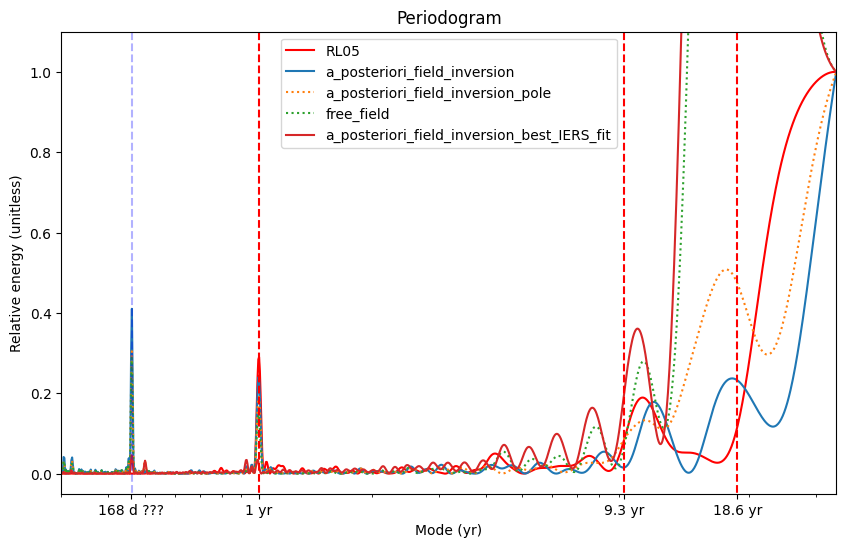

In [94]:
from plot_gravity_test import produce_uncrossed_figures, gravity_timeseries
from pathlib import Path
from pandas import TimedeltaIndex
from scipy.signal import lombscargle
from matplotlib.pyplot import (
    semilogx,
    vlines,
    legend,
    figure,
    xlim,
    ylim,
    title,
    xlabel,
    ylabel,
    xticks,
)
from numpy import logspace, pi, array, log10
from scipy.signal import detrend
from plot_gravity_test import ParameterType

fig = figure(figsize=(10, 6))
freqs = 2 * pi / logspace(log10(0.3), log10(34), 1000, 10)
reference_dates, reference_values, reference_uncertainties = gravity_timeseries()
time_deltas: TimedeltaIndex = reference_dates - reference_dates[0]
reference_t = time_deltas.days / 365.25
reference_periodogram = lombscargle(
    x=reference_t, y=detrend(reference_values["C_20"]), freqs=freqs, normalize=True
)
semilogx(
    2 * pi / freqs,
    reference_periodogram / reference_periodogram[-1],
    label="RL05",
    color="red",
)

for file_name, color, linestyle in zip(
    [
        "a_posteriori_field_inversion",
        "a_posteriori_field_inversion_pole",
        "free_field",
        "a_posteriori_field_inversion_best_IERS_fit"
    ],
    ["blue", "purple", "orange", "red"],
    ["-", ":", ":", "-"],
):

    solutions, _, _ = produce_uncrossed_figures(
        root=Path("."),
        file=Path(file_name),
        output_root=Path("."),
        reference_dates=reference_dates,
        reference_field=(reference_values, reference_uncertainties),
        get_anyway=True,
    )
    dates = array(
        [
            parameter[3]
            for parameter in solutions.keys()
            if parameter[0] == ParameterType.C
            and parameter[1] == 2
            and parameter[2] == 0
            and parameter[3] is not None
        ]
    )
    dates.sort()
    values = array([solutions[(ParameterType.C, 2, 0, date, None)] for date in dates])
    time_deltas: TimedeltaIndex = dates - dates[0]
    t = array([time.days for time in time_deltas]) / 365.25
    t, values = remove_outliers(t, detrend(values))
    periodogram = lombscargle(x=t, y=values, freqs=freqs, normalize=True)
    semilogx(2 * pi / freqs, periodogram / periodogram[-1], label=file_name, linestyle=linestyle)

vlines(
    array([1, 9.3, 18.6]),
    ymin=-1,
    ymax=2,
    linestyles="--",
    colors="red",
)
vlines(169 / 365, ymin=-1, ymax=2, linestyles="--", colors="blue", alpha=0.3)
ylim(-0.05, 1.1)
xlim(0.3, 34)
legend(loc="upper center")
xlabel("Mode (yr)")
ylabel("Relative energy (unitless)")
title("Periodogram")
xticks(
    ticks=[168 / 365.25, 1, 9.3, 18.6],
    labels=[
        r"168 d ???",
        "1 yr",
        "9.3 yr",
        "18.6 yr",
    ],
)
fig.savefig("periodogram.pdf")

In [134]:
0.0833-(28/365.25)

0.006640177960301169

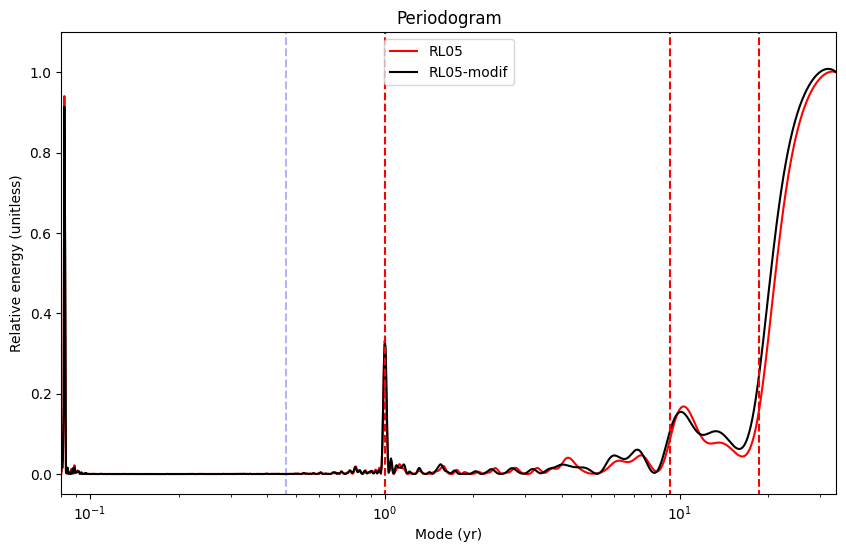

In [ ]:
from plot_gravity_test import gravity_timeseries
from pandas import TimedeltaIndex
from scipy.signal import lombscargle
from matplotlib.pyplot import (
    semilogx,
    vlines,
    legend,
    figure,
    xlim,
    ylim,
    title,
    xlabel,
    ylabel,
)
from numpy import logspace, pi, array, log10
from scipy.signal import detrend
from scipy.interpolate import interp1d

fig = figure(figsize=(10, 6))
freqs = 2 * pi / logspace(log10(0.08), log10(34), 1000, 10)
reference_dates, reference_values, reference_uncertainties = gravity_timeseries(start="1991-08-09")
time_deltas: TimedeltaIndex = reference_dates - reference_dates[0]
reference_t = time_deltas.days / 365.25
reference_periodogram = lombscargle(
    x=reference_t, y=detrend(reference_values["C_20"]), freqs=freqs, normalize=True
)
semilogx(
    2 * pi / freqs,
    reference_periodogram / reference_periodogram[-1],
    label="RL05",
    color="red",
)
f = interp1d(reference_t, reference_values["C_20"])
reference_periodogram = lombscargle(
    x=t, y=detrend(f(t)), freqs=freqs, normalize=True
)
semilogx(
    2 * pi / freqs,
    reference_periodogram / reference_periodogram[-1],
    label="RL05-modif",
    color="black",
)

vlines(
    array([1, 9.3, 18.6]),
    ymin=-1,
    ymax=2,
    linestyles="--",
    colors="red",
)
vlines(169 / 365, ymin=-1, ymax=2, linestyles="--", colors="blue", alpha=0.3)
ylim(-0.05, 1.1)
xlim(0.08, 34)
legend(loc="upper center")
xlabel("Mode (yr)")
ylabel("Relative energy (unitless)")
title("Periodogram")
fig.savefig("periodogram.pdf")

In [95]:
from plot_gravity_test import gravity_timeseries, produce_uncrossed_figures
from pathlib import Path

reference_dates, reference_values, reference_uncertainties = gravity_timeseries(start="1991-08-09")

solutions, _, _ = produce_uncrossed_figures(
    root=Path("."),
    file=Path("a_posteriori_field_inversion_best_IERS_fit"),
    output_root=Path("."),
    reference_dates=reference_dates,
    reference_field=(reference_values, reference_uncertainties),
    get_anyway=True,
)